In [27]:
!pip install albumentations
!pip install opencv-python

# 0. Library Importation

In [ ]:
import os
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torchvision

from sklearn.model_selection import train_test_split

In [29]:
print("All libraries imported successfully")
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("OpenCV version:", cv2.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Please enable GPU in Kaggle settings.")

!nvidia-smi

All libraries imported successfully
PyTorch version: 2.10.0+cpu
Torchvision version: 0.25.0+cpu
OpenCV version: 4.13.0
CUDA available: False
Device: cpu
GPU is not available. Please enable GPU in Kaggle settings.
/bin/bash: line 1: nvidia-smi: command not found


In [30]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 1. Source Dataset Load

In [31]:
# ===== PATH =====
BASE_PATH = "/kaggle/input/datasets/khoongweihao/chasedb1/"

all_files = sorted(os.listdir(BASE_PATH))
print(f"Số lượng file: {len(all_files)}")
print("\n10 file đầu tiên:")
for f in all_files[:10]:
    print(" ", f)

Số lượng file: 84

10 file đầu tiên:
  Image_01L.jpg
  Image_01L_1stHO.png
  Image_01L_2ndHO.png
  Image_01R.jpg
  Image_01R_1stHO.png
  Image_01R_2ndHO.png
  Image_02L.jpg
  Image_02L_1stHO.png
  Image_02L_2ndHO.png
  Image_02R.jpg


In [32]:
# ===== LOAD ALL PATH =====
image_paths    = []
manual_1_paths = []
manual_2_paths = []

for fname in sorted(all_files):
    if fname.endswith(".jpg") and fname.startswith("Image_"):
        img_id = fname.replace(".jpg", "")
        
        manual_1_name = f"{img_id}_1stHO.png"
        manual_2_name = f"{img_id}_2ndHO.png"

        # Append if both manual images exist
        if (
            os.path.exists(os.path.join(BASE_PATH, manual_1_name)) and
            os.path.exists(os.path.join(BASE_PATH, manual_2_name))
        ):
            image_paths.append(os.path.join(BASE_PATH, fname))
            manual_1_paths.append(os.path.join(BASE_PATH, manual_1_name))
            manual_2_paths.append(os.path.join(BASE_PATH, manual_2_name))

print(f"Tổng số ảnh: {len(image_paths)}")
print("\nẢnh mẫu:")
for i in range(min(3, len(image_paths))):
    print(f"  Image   : {os.path.basename(image_paths[i])}")
    print(f"  Manual1 : {os.path.basename(manual_1_paths[i])}")
    print(f"  Manual2 : {os.path.basename(manual_2_paths[i])}")
    print()

Tổng số ảnh: 28

Ảnh mẫu:
  Image   : Image_01L.jpg
  Manual1 : Image_01L_1stHO.png
  Manual2 : Image_01L_2ndHO.png

  Image   : Image_01R.jpg
  Manual1 : Image_01R_1stHO.png
  Manual2 : Image_01R_2ndHO.png

  Image   : Image_02L.jpg
  Manual1 : Image_02L_1stHO.png
  Manual2 : Image_02L_2ndHO.png



In [33]:
# ===== SPLIT TRAIN / VAL / TEST =====
# Split test
train_val_img, test_img, train_val_m1, test_m1, train_val_m2, test_m2 = train_test_split(
    image_paths, manual_1_paths, manual_2_paths, test_size=4, random_state=42
)

# Split val
train_img, val_img, train_m1, val_m1, train_m2, val_m2 = train_test_split(
    train_val_img, train_val_m1, train_val_m2, test_size=4, random_state=42
)

In [34]:
# ===== CHECK SIZE =====
print(f"Train : {len(train_img)}")
print(f"Val   : {len(val_img)}")
print(f"Test  : {len(test_img)}")

Train : 20
Val   : 4
Test  : 4


In [35]:
# ===== CHECK SAMPLE INFO =====
sample_img    = np.array(Image.open(train_img[0]))
sample_m1     = np.array(Image.open(train_m1[0])).astype(np.uint8) * 255
sample_m2     = np.array(Image.open(train_m2[0])).astype(np.uint8) * 255

print("Thông tin sample")
print(f"Shape ảnh gốc   : {sample_img.shape}")   # (H, W, 3)
print(f"Shape manual 1  : {sample_m1.shape}")     # (H, W) hoặc (H, W, 3)
print(f"Shape manual 2  : {sample_m2.shape}")
print(f"\nManual 1 unique values: {np.unique(sample_m1)}")
print(f"Manual 2 unique values: {np.unique(sample_m2)}")

Thông tin sample
Shape ảnh gốc   : (960, 999, 3)
Shape manual 1  : (960, 999)
Shape manual 2  : (960, 999)

Manual 1 unique values: [  0 255]
Manual 2 unique values: [  0 255]


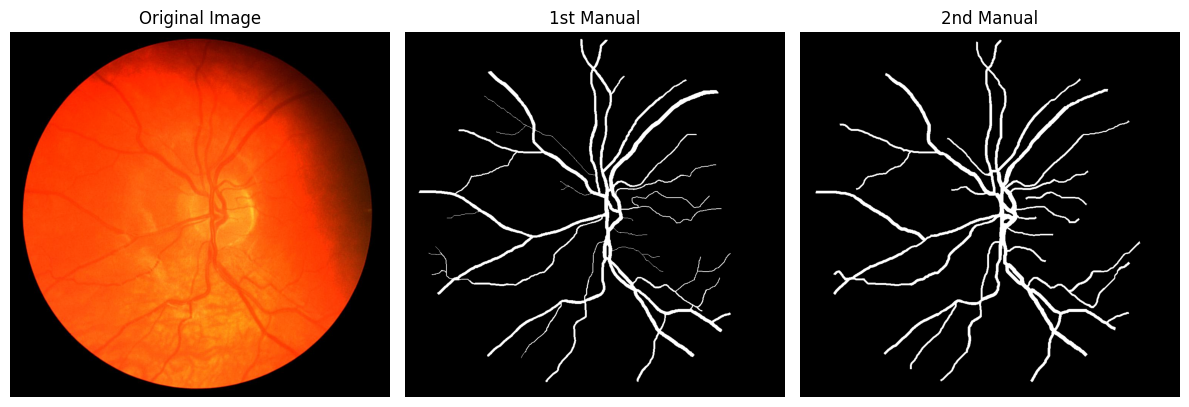

In [36]:
# ===== SHOW BASE + MANUAL 1 + MANUAL 2 =====
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(sample_img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sample_m1, cmap='gray')
plt.title("1st Manual")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sample_m2, cmap='gray')
plt.title("2nd Manual")
plt.axis('off')

plt.tight_layout()
plt.show()

# 2. Transfer Dataset Load

In [37]:
# ===== PATH =====
BASE_PATH = "/kaggle/input/datasets/zionfuo/drive2004/DRIVE/"

train_img_dir = os.path.join(BASE_PATH, "training/images")
train_mask_dir = os.path.join(BASE_PATH, "training/mask")
train_manual_dir = os.path.join(BASE_PATH, "training/1st_manual")

test_img_dir = os.path.join(BASE_PATH, "test/images")
test_mask_dir = os.path.join(BASE_PATH, "test/mask")
test_manual_1_dir = os.path.join(BASE_PATH, "test/1st_manual")
test_manual_2_dir = os.path.join(BASE_PATH, "test/2nd_manual")

In [38]:
# ===== LOAD TRAIN =====
train_images = sorted(os.listdir(train_img_dir))

train_image_paths = []
train_mask_paths = []
train_manual_paths = []

for img_name in train_images:
    img_id = img_name.split('_')[0]
    manual_name = f"{img_id}_manual1.gif"
    mask_name = f"{img_id}_training_mask.gif"
    
    train_image_paths.append(os.path.join(train_img_dir, img_name))
    train_manual_paths.append(os.path.join(train_manual_dir, manual_name))
    train_mask_paths.append(os.path.join(train_mask_dir, mask_name))

In [39]:
# ===== SPLIT TRAIN - VAL =====
train_image_paths, val_image_paths, train_mask_paths, val_mask_paths, train_manual_paths, val_manual_paths = train_test_split(
    train_image_paths, train_mask_paths, train_manual_paths,
    test_size=4, 
    random_state=42
)

In [40]:
# ===== LOAD TEST =====
test_images = sorted(os.listdir(test_img_dir))

test_image_paths = []
test_mask_paths = []
test_manual_1_paths = []
test_manual_2_paths = []

for img_name in test_images:
    img_id = img_name.split('_')[0]
    mask_name = f"{img_id}_test_mask.gif"
    manual_1_name = f"{img_id}_manual1.gif"
    manual_2_name = f"{img_id}_manual2.gif"
    
    test_image_paths.append(os.path.join(test_img_dir, img_name))
    test_mask_paths.append(os.path.join(test_mask_dir, mask_name))
    test_manual_1_paths.append(os.path.join(test_manual_1_dir, manual_1_name))
    test_manual_2_paths.append(os.path.join(test_manual_2_dir, manual_2_name))

In [41]:
# ===== CHECK SIZE =====
print("Train:", len(train_image_paths))
print("Test :", len(test_image_paths))
print('Val  :', len(val_image_paths))

Train: 16
Test : 20
Val  : 4


In [42]:
# ===== CHECK SAMPLE INFO =====
sample_img_path = train_image_paths[0]
sample_manual_path = train_manual_paths[0]
sample_mask_path = train_mask_paths[0]

img = np.array(Image.open(sample_img_path))
mask = np.array(Image.open(sample_mask_path))
manual = np.array(Image.open(sample_manual_path))

print("\nThông tin sample")
print(f"Shape ảnh gốc : {img.shape}")   # (H, W, 3)
print(f"Shape mask    : {mask.shape}")  # (H, W)
print(f"Shape manual  : {manual.shape}")  # (H, W)


Thông tin sample
Shape ảnh gốc : (584, 565, 3)
Shape mask    : (584, 565)
Shape manual  : (584, 565)


In [43]:
# ===== CHECK SHAPE & MASK VALUE =====
unique_values = np.unique(mask)
print(f"Giá trị pixel trong mask: {unique_values}") 

Giá trị pixel trong mask: [  0 255]


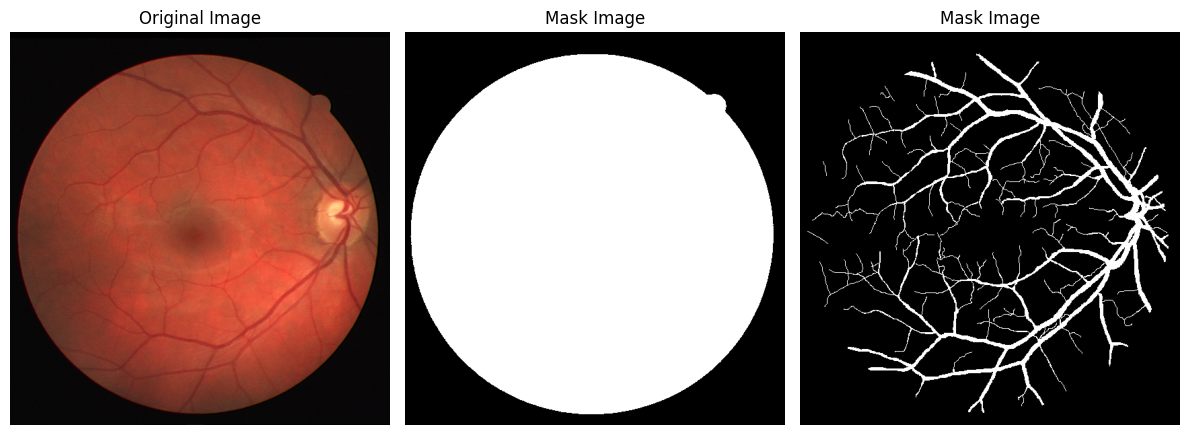

In [44]:
# ===== SHOW BASE + MASK + MANUAL =====
plt.figure(figsize=(12, 6))

# Base
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

# Mask
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("Mask Image")
plt.axis('off')

# Manual
plt.subplot(1, 3, 3)
plt.imshow(manual, cmap='gray')
plt.title("Mask Image")
plt.axis('off')

plt.tight_layout()
plt.show()